# CNN Model

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [29]:
import warnings
warnings.filterwarnings('ignore')

In [30]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [31]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [32]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [33]:
X, y = mnist.data, mnist.target

In [34]:
df = pd.DataFrame(X)

In [35]:
df_test = pd.DataFrame(y)

In [36]:
print(f'X shape: {df.shape}')
print(f'y shape: {df_test.shape}')

X shape: (70000, 784)
y shape: (70000, 1)


In [37]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
df.columns

RangeIndex(start=0, stop=784, step=1)

In [39]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
779,0
780,0
781,0
782,0


In [40]:
df.isnull().sum().sum()

np.int64(0)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(df, df_test, test_size=0.25, random_state=42)

In [44]:
"""
As we see we have total 784 columns
Each image is a 28x28 pixel grayscale image
Each row has 28 pixels
Each column has 28 pixels
total 28*28 = 784 pixels
For each image, there are 784 pixels

One row represents one image
"""
X_train

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
58774,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63662,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54551,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6265,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
54886,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
X_train.shape

(52500, 784)

In [46]:
# To convert the X (input) data between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32')  / 255.0

In [48]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
58774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
63662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54551,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54886,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
"""
reshaping the data to a 28*28 pixel grayscale image

reshape() - changes the shape of the array without changing the data in the array.

parameters
------------
newshape : int or tuple of ints
The new shape should be compatible with the original shape.
If an integer, then the result will be
an array of that length.
One shape dimension can be -1. In this case,
the value is inferred from the length of the array
and remaining dimensions.


"""

X_train_img = X_train.values.reshape(-1, 28, 28)
X_test_img = X_test.values.reshape(-1, 28, 28)

In [53]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [54]:
# One hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [57]:
y_train_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

## Perceptron

In [58]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

In [59]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [61]:
# Tain the model
history_percp= perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9027 - loss: 0.3522 - val_accuracy: 0.9042 - val_loss: 0.3516
Epoch 2/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9016 - loss: 0.3470 - val_accuracy: 0.9050 - val_loss: 0.3440
Epoch 3/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9054 - loss: 0.3390 - val_accuracy: 0.9069 - val_loss: 0.3381
Epoch 4/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9074 - loss: 0.3301 - val_accuracy: 0.9083 - val_loss: 0.3327
Epoch 5/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9091 - loss: 0.3238 - val_accuracy: 0.9100 - val_loss: 0.3284


In [62]:
accurecy_percp_model = perceptron.evaluate(X_test_img, y_test_cat)

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9111 - loss: 0.3251


In [65]:
accurecy_percp_model

[0.32839933037757874, 0.9100000262260437]

In [64]:
accurecy_percp_model[1]

0.9100000262260437

## ANN

In [67]:
#ANN

ann = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])

In [70]:
ann.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [72]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9903 - loss: 0.0301 - val_accuracy: 0.9710 - val_loss: 0.1074
Epoch 2/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9921 - loss: 0.0240 - val_accuracy: 0.9750 - val_loss: 0.1018
Epoch 3/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9924 - loss: 0.0234 - val_accuracy: 0.9737 - val_loss: 0.1096
Epoch 4/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9735 - val_loss: 0.1153
Epoch 5/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9938 - loss: 0.0181 - val_accuracy: 0.9758 - val_loss: 0.1058


In [73]:
accuracy_ann = ann.evaluate(X_test_img, y_test_cat)

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.1084


# CNN

In [75]:
# reshape(-1, 28, 28, 1) - the forth parameter is for colour channels
# for grayscale we will keep like this

X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

# For RGB it should be - reshape(-1, 28, 28, 3)

# X_train_cnn = X_train.reshape(-1, 28, 28, 3)
# X_test_cnn = X_test.reshape(-1, 28, 28, 3)

In [76]:
# CNN
# kernel_size is basically the filter size
# pool_size=(2,2) - it will go to 2X2 pxel size and bring out the max value


cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"), # starting of hidden layer
    Dropout(0.5), # 50% neuron will be deactivated randomly
    Dense(10, activation="softmax")
])

In [77]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [78]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.8583 - loss: 0.4441 - val_accuracy: 0.9817 - val_loss: 0.0576
Epoch 2/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 56s 34ms/step - accuracy: 0.9763 - loss: 0.0815 - val_accuracy: 0.9865 - val_loss: 0.0427
Epoch 3/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9827 - loss: 0.0575 - val_accuracy: 0.9899 - val_loss: 0.0351
Epoch 4/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9864 - loss: 0.0444 - val_accuracy: 0.9877 - val_loss: 0.0393
Epoch 5/5
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.9881 - loss: 0.0382 - val_accuracy: 0.9911 - val_loss: 0.0283


In [79]:
accuracy_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=1)

547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9911 - loss: 0.0274


In [80]:
accuracy_cnn[1]

0.9911428689956665

In [84]:
def plot_training(history, title):
  plt.figure(figsize=(12, 4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{title} - Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.tight_layout()

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{title} - Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.tight_layout()

  plt.show()

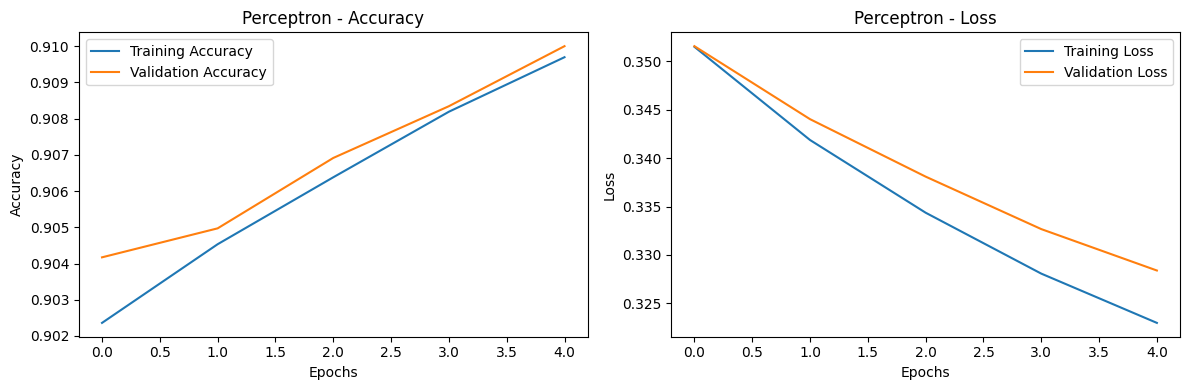

In [85]:
plot_training(history_percp, "Perceptron")

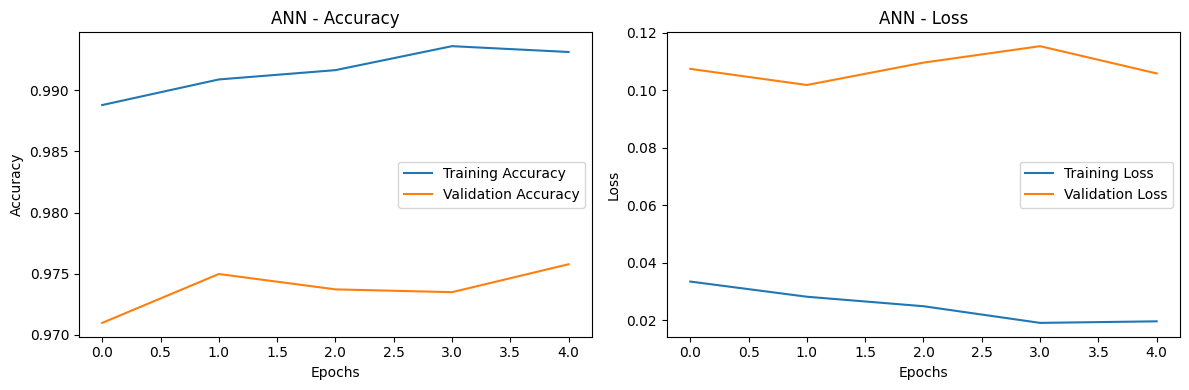

In [86]:
plot_training(history_ann, "ANN")

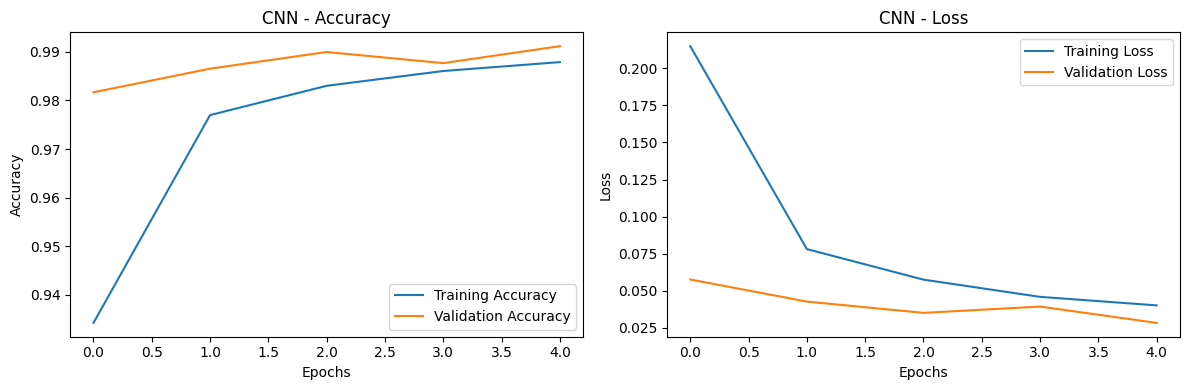

In [87]:
plot_training(history_cnn, "CNN")

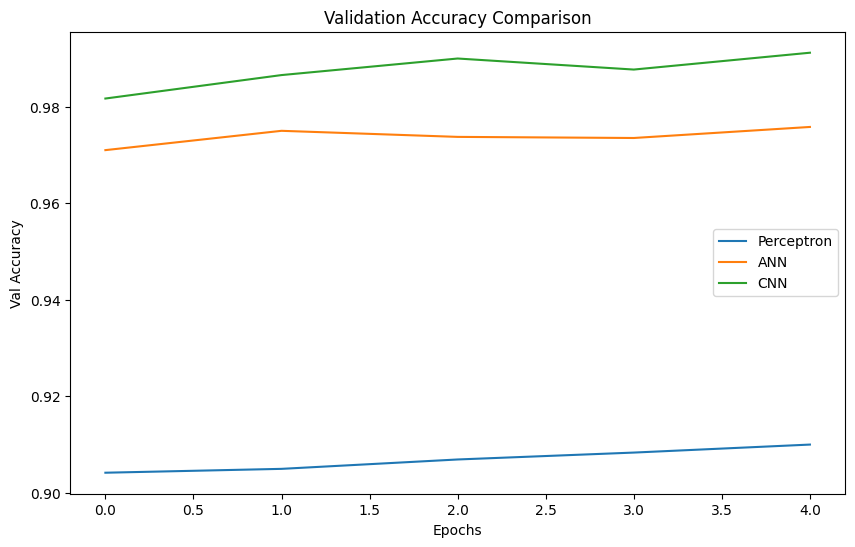

In [88]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [95]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true.iloc[idx].item()}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━

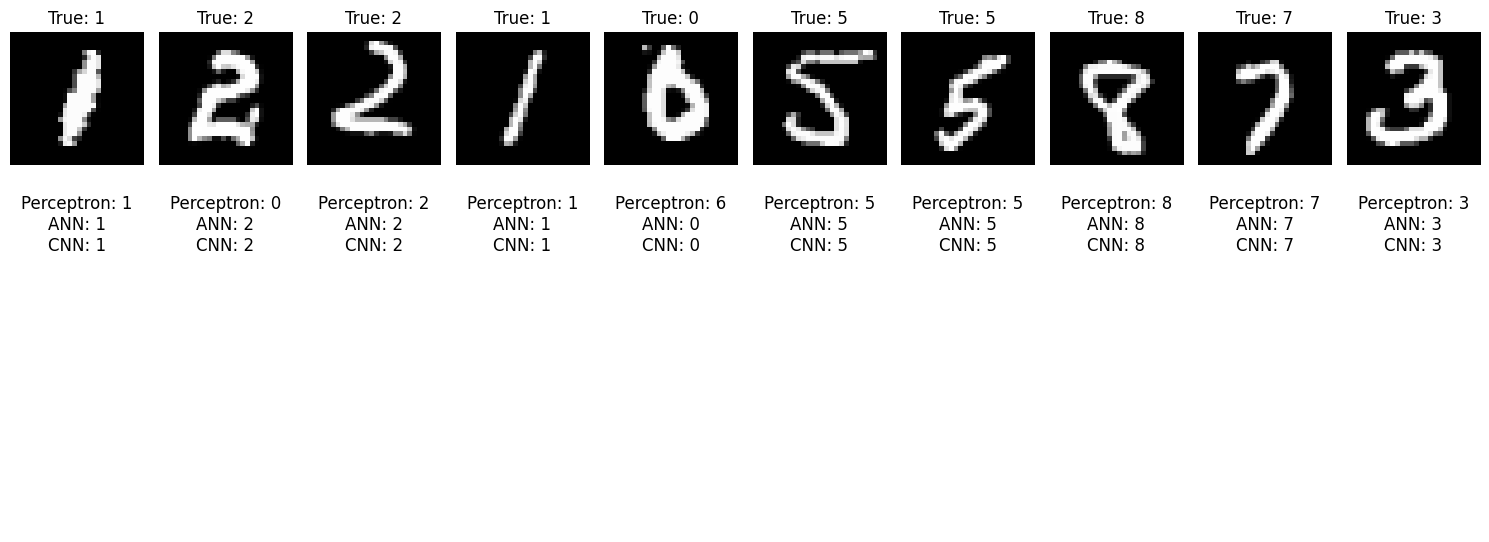

In [98]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 10)

547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


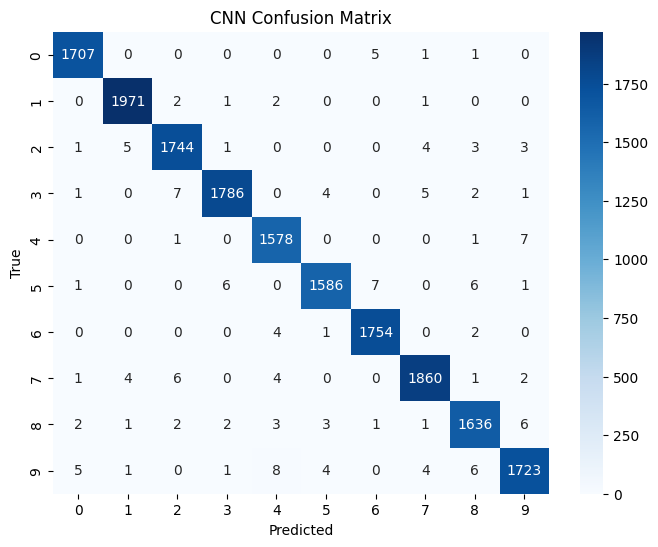

In [100]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test.astype(int), y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


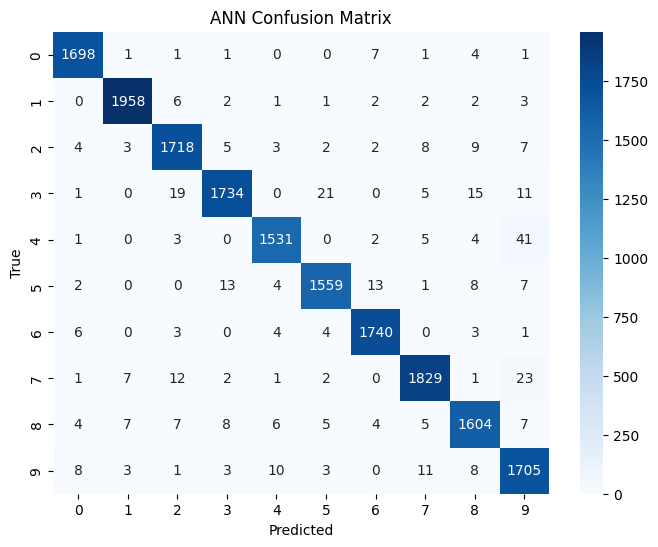

In [101]:
y_pred_ann = np.argmax(ann.predict(X_test_img), axis=1)
cm = confusion_matrix(y_test.astype(int), y_pred_ann)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

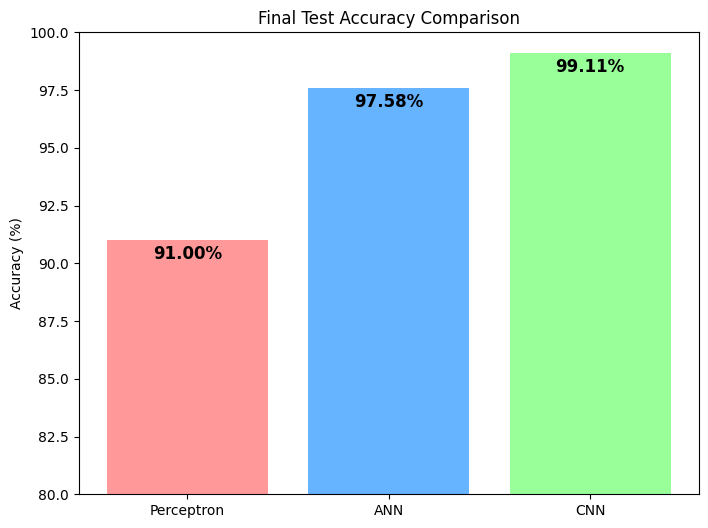

In [102]:
final_accs = [accurecy_percp_model[1]*100, accuracy_ann[1]*100, accuracy_cnn[1]*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()